<a href="https://colab.research.google.com/github/sheepwool/CS123A_TermProject/blob/main/CS123A_TermProject_DanaShakrovsky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Classification Using Multi-Layer Perceptron
by Dana Shakrovsky

[Link to Secondary Mushroom Dataset](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)


# Import packages and libraries

In [ ]:
# Import packages and libraries

# Pandas
import pandas as pd

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

# Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model

# Numpy
import numpy as np

# Plots
import matplotlib.pyplot as plt


In [ ]:
# Install ucimlrepo package
!pip install ucimlrepo

# Import dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
secondary_mushroom = fetch_ucirepo(id=848)

# data (as pandas dataframes)
X = secondary_mushroom.data.features
y = secondary_mushroom.data.targets

# metadata
print(secondary_mushroom.metadata)

# variable information
print(secondary_mushroom.variables)


{'uci_id': 848, 'name': 'Secondary Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/848/data.csv', 'abstract': 'Dataset of simulated mushrooms for binary classification into edible and poisonous.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 61068, 'num_features': 20, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2021, 'last_updated': 'Wed Apr 10 2024', 'dataset_doi': '10.24432/C5FP5Q', 'creators': ['Dennis Wagner', 'D. Heider', 'Georges Hattab'], 'intro_paper': {'ID': 259, 'type': 'NATIVE', 'title': 'Mushroom data creation, curation, and simulation to support classification tasks', 'authors': 'Dennis Wagner, D. Heider, Georges Hattab', 'venue': 'Scientific Reports', 'year': 2021, 'journal': None, '

# Check Missing Values

Determine the percentage of NaN values in the columns for which UC Irvine indicated contain missing values. Depending on how much is missing, the columns will either be removed or will have the missing data imputed.

In [ ]:
# display data in its current state before modifications
print("Total number of samples: " + str(X.shape[0]))
X.head()

Total number of samples: 61069


,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [ ]:
# determine percentage of NaN values in each column that contains missing values

# cap-surface column
cap_surface_col = X['cap-surface']
print(f"Number of NaN values in column 'cap-surface': {cap_surface_col.isna().sum().sum()}")
print("{:.2f}%\n".format((cap_surface_col.isna().sum().sum()/X.shape[0]) * 100))

# gill-attachment column
gill_attachment_col = X['gill-attachment']
print(f"Number of NaN values in column 'gill-attachment': {gill_attachment_col.isna().sum().sum()}")
print("{:.2f}%\n".format((gill_attachment_col.isna().sum().sum()/X.shape[0]) * 100))

# gill-spacing column
gill_spacing_col = X['gill-spacing']
print(f"Number of NaN values in column 'gill-spacing': {gill_spacing_col.isna().sum().sum()}")
print("{:.2f}%\n".format((gill_spacing_col.isna().sum().sum()/X.shape[0]) * 100))

# stem-root column
stem_root_col = X['stem-root']
print(f"Number of NaN values in column 'stem-root': {stem_root_col.isna().sum().sum()}")
print("{:.2f}%\n".format((stem_root_col.isna().sum().sum()/X.shape[0]) * 100))

# stem-surface column
stem_surface_col = X['stem-surface']
print(f"Number of NaN values in column 'stem-surface': {stem_surface_col.isna().sum().sum()}")
print("{:.2f}%\n".format((stem_surface_col.isna().sum().sum()/X.shape[0]) * 100))

# veil-color column
veil_color_col = X['veil-color']
print(f"Number of NaN values in column 'veil-color': {veil_color_col.isna().sum().sum()}")
print("{:.2f}%\n".format((veil_color_col.isna().sum().sum()/X.shape[0]) * 100))

# ring-type column
ring_type_col = X['ring-type']
print(f"Number of NaN values in column 'ring-type': {ring_type_col.isna().sum().sum()}")
print("{:.2f}%\n".format((ring_type_col.isna().sum().sum()/X.shape[0]) * 100))

# spore-print-color column
spore_print_color_col = X['spore-print-color']
print(f"Number of NaN values in column 'spore-print-color': {spore_print_color_col.isna().sum().sum()}")
print("{:.2f}%\n".format((spore_print_color_col.isna().sum().sum()/X.shape[0]) * 100))

Number of NaN values in column 'cap-surface': 14120
23.12%

Number of NaN values in column 'gill-attachment': 9884
16.18%

Number of NaN values in column 'gill-spacing': 25063
41.04%

Number of NaN values in column 'stem-root': 51538
84.39%

Number of NaN values in column 'stem-surface': 38124
62.43%

Number of NaN values in column 'veil-color': 53656
87.86%

Number of NaN values in column 'ring-type': 2471
4.05%

Number of NaN values in column 'spore-print-color': 54715
89.60%



In [ ]:
# remove columns with greater than 20% of missing values
X_set = X.drop(['cap-surface', 'gill-spacing', 'stem-root', 'stem-surface','veil-color','spore-print-color'], axis=1)
X_set.head()

,cap-diameter,cap-shape,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-color,veil-type,has-ring,ring-type,habitat,season
0,15.26,x,o,f,e,w,16.95,17.09,w,u,t,g,d,w
1,16.60,x,o,f,e,w,17.99,18.19,w,u,t,g,d,u
2,14.07,x,o,f,e,w,17.80,17.74,w,u,t,g,d,w
3,14.17,f,e,f,e,w,15.77,15.98,w,u,t,p,d,w
4,14.64,x,o,f,e,w,16.53,17.20,w,u,t,p,d,w


In [ ]:
# impute missing data for columns with less than 20% missing values

# gill-attachment column
X_set['gill-attachment-n'] = pd.factorize(X_set['gill-attachment'], sort=True)[0] # first convert to numeric values
gill_attachment_n_col = ['gill-attachment-n']
for i in gill_attachment_n_col:
  X_set.loc[X_set.loc[:,i].isnull(), i]=X_set.loc[:,i].median() # replace NaN values with median

# ring-type column
X_set['ring-type-n'] = pd.factorize(X_set['ring-type'], sort=True)[0] # first convert to numeric values
ring_type_n_col = ['ring-type-n']
for i in ring_type_n_col:
  X_set.loc[X_set.loc[:,i].isnull(), i]=X_set.loc[:,i].median() # replace NaN values with median

# print results
X_clean = X_set.drop(['gill-attachment', 'ring-type'], axis=1)
print(f"Number of NaN values after imputation for column 'gill-attachment':\n{X_clean['gill-attachment-n'].isna().sum().sum()}")
print(f"\nNumber of NaN values after imputation for column 'ring-type':\n{X_clean['ring-type-n'].isna().sum().sum()}")

Number of NaN values after imputation for column 'gill-attachment':
0

Number of NaN values after imputation for column 'ring-type':
0


# Convert categories into numeric values
Out of the 20 total columns in X provided, 14 columns remain after data cleaning. Each column contains either numeric or categorical data.
For columns containing categorical data, the categories for each will be transformed to numeric data as follows:

**cap-shape:**

b(bell) = 0, c(conical) = 1, f(flat) = 2, o(others) = 3, p(spherical) = 4, s(sunken) = 5, x(convex) = 6


**cap-color:**

b(buff) = 0, e(red) = 1, g(gray) = 2, k(black) = 3, l(blue) = 4, n(brown) = 5, o(orange) = 6, p(pink) = 7, r(green) = 8, u(purple) = 9, w(white) = 10, y(yellow) = 11

**does-bruise-or-bleed:**

f(false) = 0, t(true) = 1


**gill-attachment:**

a(adnate) = 0, d(decurrent) = 1, e(free) = 2, f(none) = 3, p(pores) = 4, s(sinuate) = 5, x(adnexed) = 6

(unknown (?) values not included after data imputation)


**gill-color:**

b(buff) = 0, e(red) = 1, f(none) = 2, g(gray) = 3, k(black) = 4, l(blue) = 5, n(brown) = 6, o(orange) = 7, p(pink) = 8, r(green) = 9, u(purple) = 10, w(white) = 11, y(yellow) = 12

**stem-color:**

b(buff) = 0, e(red) = 1, f(none) = 2, g(gray) = 3, k(black) = 4, l(blue) = 5, n(brown) = 6, o(orange) = 7, p(pink) = 8, r(green) = 9, u(purple) = 10, w(white) = 11, y(yellow) = 12

**veil-type:**

p(partial) = 0, u(universal) = 1


**has-ring:**

f(false) = 0, t(true) = 1

**ring-type:**

c(cobwebby) = 0, e(evanescent) = 1, f(none) = 2, g(grooved) = 3, l(large) = 4, m(movable) = 5, p(pendant) = 6, r(flaring) = 7, s(sheathing) = 8, y(scaly) = 9, z(zone) = 10

(unknown (?) values not included after data imputation)

**habitat:**

d(woods) = 0, g(grasses) = 1, h(heaths) = 2, l(leaves) = 3, m(meadows) = 4, p(paths) = 5, u(urban) = 6, w(waste) = 7

**season:**

a(autumn) = 0,  s(spring) = 1, u(summer) = 2, w(winter) = 3



---



In addition to converting the values in X, the target (y) will also be converted. The original labels are edible=e and poisonous=p. These will be converted to 0 for edible, and 1 for poisonous to indicate whether the mushroom is poisonous or not.


In [ ]:
# cap-shape column
X_clean['cap-shape-n'] = pd.factorize(X_clean['cap-shape'], sort=True)[0]

# cap-color column
X_clean['cap-color-n'] = pd.factorize(X_clean['cap-color'], sort=True)[0]

# does-bruise-bleed column
X_clean['does-bruise-or-bleed-n'] = pd.factorize(X_clean['does-bruise-or-bleed'], sort=True)[0]

# gill-color column
X_clean['gill-color-n'] = pd.factorize(X_clean['gill-color'], sort=True)[0]

# stem-color column
X_clean['stem-color-n'] = pd.factorize(X_clean['stem-color'], sort=True)[0]

# veil-type column
X_clean['veil-type-n'] = pd.factorize(X_clean['veil-type'], sort=True)[0]

# has-ring  column
X_clean['has-ring-n'] = pd.factorize(X_clean['has-ring'], sort=True)[0]

# habitat column
X_clean['habitat-n'] = pd.factorize(X_clean['habitat'], sort=True)[0]

# season column
X_clean['season-n'] = pd.factorize(X_clean['season'], sort=True)[0]

# drop the original columns w/ categories
X_final = X_clean.drop(['cap-shape', 'cap-color', 'does-bruise-or-bleed', 'gill-color', 'stem-color','veil-type','has-ring','habitat','season'], axis=1)

X_final.head()

,cap-diameter,stem-height,stem-width,gill-attachment-n,ring-type-n,cap-shape-n,cap-color-n,does-bruise-or-bleed-n,gill-color-n,stem-color-n,veil-type-n,has-ring-n,habitat-n,season-n
0,15.26,16.95,17.09,2,2,6,6,0,10,11,0,1,0,3
1,16.60,17.99,18.19,2,2,6,6,0,10,11,0,1,0,2
2,14.07,17.80,17.74,2,2,6,6,0,10,11,0,1,0,3
3,14.17,15.77,15.98,2,5,2,1,0,10,11,0,1,0,3
4,14.64,16.53,17.20,2,5,6,6,0,10,11,0,1,0,3


In [ ]:
# convert target to binary numeric values
y_set = y.copy()
y_set['isPoisonous'] = pd.factorize(y['class'], sort=True)[0]
y_final = y_set.drop(['class'], axis=1)
y_final.head()

,isPoisonous
0,1
1,1
2,1
3,1
4,1


# Split dataset into training and testing sets
The ratio of training, validation, and test data is 80:10:10 (validation set will be split from the training set during training)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.1, random_state=0)

# Create Multi-Layer Perceptron model

In [ ]:
multi_perceptron = tf.keras.models.Sequential(layers=[
  # Input layer
  tf.keras.layers.Input(shape=(X_train.shape[1],)),

  # Inner layer
  tf.keras.layers.Dense(128, activation='sigmoid'),   # inner layer with 125 nodes, activation function = sigmoid

  # Output layer
  tf.keras.layers.Dense(1, activation='sigmoid')    # activation function = sigmoid
  ],
  trainable=True,
  name='Multi-layer_Perceptron'
)

# Compile
multi_perceptron.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

multi_perceptron.summary()


Model: "Multi-layer_Perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = multi_perceptron.fit(
    x=X_train,
    y=y_train,
    epochs=10,
    batch_size=8,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10
6184/6184 - 28s - 4ms/step - accuracy: 0.7099 - loss: 0.5536 - val_accuracy: 0.7802 - val_loss: 0.4639
Epoch 2/10
6184/6184 - 13s - 2ms/step - accuracy: 0.8319 - loss: 0.3822 - val_accuracy: 0.8667 - val_loss: 0.3249
Epoch 3/10
6184/6184 - 12s - 2ms/step - accuracy: 0.8981 - loss: 0.2684 - val_accuracy: 0.9263 - val_loss: 0.2264
Epoch 4/10
6184/6184 - 21s - 3ms/step - accuracy: 0.9338 - loss: 0.1965 - val_accuracy: 0.9462 - val_loss: 0.1745
Epoch 5/10
6184/6184 - 20s - 3ms/step - accuracy: 0.9541 - loss: 0.1502 - val_accuracy: 0.9647 - val_loss: 0.1259
Epoch 6/10
6184/6184 - 14s - 2ms/step - accuracy: 0.9646 - loss: 0.1183 - val_accuracy: 0.9709 - val_loss: 0.1036
Epoch 7/10
6184/6184 - 20s - 3ms/step - accuracy: 0.9713 - loss: 0.0967 - val_accuracy: 0.9756 - val_loss: 0.0858
Epoch 8/10
6184/6184 - 14s - 2ms/step - accuracy: 0.9761 - loss: 0.0810 - val_accuracy: 0.9776 - val_loss: 0.0734
Epoch 9/10
6184/6184 - 20s - 3ms/step - accuracy: 0.9802 - loss: 0.0693 - val_accuracy: 

# Test the Multi-Layer Perceptron model's accuracy
Test the multi-layer perceptron with the test set, then evaluate the results with f1, accuracy, precision, and recall scores.

In [ ]:
# Test perceptron with test dataset
loss = multi_perceptron.evaluate(X_test, y_test)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.0653


In [ ]:
# get predictions
y_predictions = multi_perceptron.predict(X_test)

# convert predictions into categories
y_class_pred = []
for y_pred in y_predictions:
  # conversion rule: y_pred = 1 iff probability of category 1 ≥ 0.5
  if y_pred >= 0.5:
    y_class_pred = np.append(y_class_pred, 1)
  else:
    y_class_pred = np.append(y_class_pred, 0)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# calculate f1 score and accuracy
f1 = f1_score(y_test, y_class_pred)
accuracy = accuracy_score(y_test, y_class_pred)

# calculate precision and recall
precision = precision_score(y_test, y_class_pred)
recall = recall_score(y_test, y_class_pred)

# Confusion Matrix for Multi-Layer Perceptron

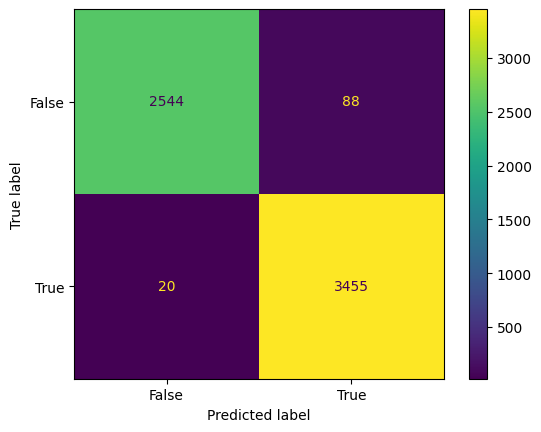


Summary of Multi-Layer Perceptron Results:

Training loss: 0.19771257638931275
Validation loss: 0.1709110178053379
Test loss: 0.5217886194586754

f1 score: 0.9846110002849815
accuracy score: 0.9823153757982643
precision score: 0.9751622918430708
recall score: 0.9942446043165467


In [ ]:
# create confusion matrix
conf_matrix = confusion_matrix(y_test, y_class_pred)
confusion_matrix_diagram = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = [False, True])

confusion_matrix_diagram.plot()
plt.show()

# print training, validation, and test losses
print("\nSummary of Multi-Layer Perceptron Results:")
print("\nTraining loss: " + str(np.array(history.history['loss']).mean()))
print("Validation loss: " + str(np.array(history.history['val_loss']).mean()))
print("Test loss: " + str(np.array(loss).mean()))

# print f1, accuracy, precision, and recall scores
print("\nf1 score: " + str(f1))
print("accuracy score: " + str(accuracy))
print("precision score: " + str(precision))
print("recall score: " + str(recall))

# Compare with Single-Layer Perceptron Model

In [ ]:
single_perceptron = tf.keras.models.Sequential(layers=[
  # Input layer
  tf.keras.layers.Input(shape=(X_train.shape[1],)),

  # Output layer
  tf.keras.layers.Dense(1, activation='sigmoid')    # activation function = sigmoid
  ],
  trainable=True,
  name='Single-layer_Perceptron'
)

# Compile
single_perceptron.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

single_perceptron.summary()

Model: "Single-layer_Perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history2 = single_perceptron.fit(
    x=X_train,
    y=y_train,
    epochs=10,
    batch_size=8,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10
6184/6184 - 13s - 2ms/step - accuracy: 0.5699 - loss: 0.7835 - val_accuracy: 0.5820 - val_loss: 0.6595
Epoch 2/10
6184/6184 - 12s - 2ms/step - accuracy: 0.6099 - loss: 0.6499 - val_accuracy: 0.6298 - val_loss: 0.6545
Epoch 3/10
6184/6184 - 11s - 2ms/step - accuracy: 0.6139 - loss: 0.6477 - val_accuracy: 0.6194 - val_loss: 0.6509
Epoch 4/10
6184/6184 - 21s - 3ms/step - accuracy: 0.6112 - loss: 0.6469 - val_accuracy: 0.5916 - val_loss: 0.6558
Epoch 5/10
6184/6184 - 21s - 3ms/step - accuracy: 0.6159 - loss: 0.6462 - val_accuracy: 0.6045 - val_loss: 0.6497
Epoch 6/10
6184/6184 - 20s - 3ms/step - accuracy: 0.6149 - loss: 0.6453 - val_accuracy: 0.6162 - val_loss: 0.6548
Epoch 7/10
6184/6184 - 12s - 2ms/step - accuracy: 0.6169 - loss: 0.6442 - val_accuracy: 0.6236 - val_loss: 0.6503
Epoch 8/10
6184/6184 - 11s - 2ms/step - accuracy: 0.6162 - loss: 0.6444 - val_accuracy: 0.6051 - val_loss: 0.6470
Epoch 9/10
6184/6184 - 11s - 2ms/step - accuracy: 0.6155 - loss: 0.6439 - val_accuracy: 

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6216 - loss: 0.6374
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


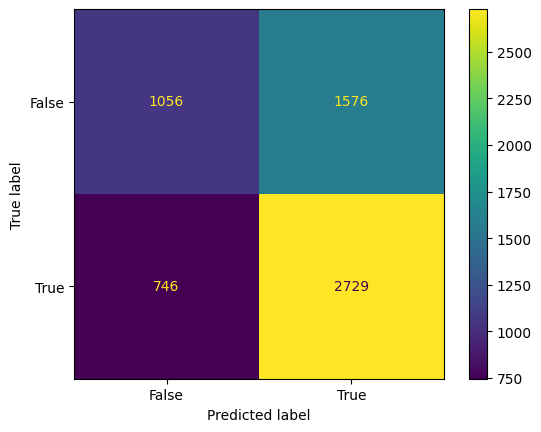


Summary of Single-Layer Perceptron Results:

Training loss: 0.6595632135868073
Validation loss: 0.6528976619243622
Test loss: 0.6283092796802521

f1 score: 0.7015424164524422
accuracy score: 0.6197805796626822
precision score: 0.6339140534262485
recall score: 0.7853237410071943


In [ ]:
# Evaluate

# Test perceptron with test dataset
loss2 = single_perceptron.evaluate(X_test, y_test)

# get predictions
y_predictions2 = single_perceptron.predict(X_test)

# convert predictions into categories
y_class_pred2 = []
for y_pred2 in y_predictions2:
  # conversion rule: y_pred = 1 iff probability of category 1 ≥ 0.5
  if y_pred2 >= 0.5:
    y_class_pred2 = np.append(y_class_pred2, 1)
  else:
    y_class_pred2 = np.append(y_class_pred2, 0)

# calculate f1 score and accuracy
f1_2 = f1_score(y_test, y_class_pred2)
accuracy_2 = accuracy_score(y_test, y_class_pred2)

# calculate precision and recall
precision_2 = precision_score(y_test, y_class_pred2)
recall_2 = recall_score(y_test, y_class_pred2)

# Confusion Matrix
conf_matrix2 = confusion_matrix(y_test, y_class_pred2)
confusion_matrix_diagram2 = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_matrix2, display_labels = [False, True])

confusion_matrix_diagram2.plot()
plt.show()

# print training, validation, and test losses
print("\nSummary of Single-Layer Perceptron Results:")
print("\nTraining loss: " + str(np.array(history2.history['loss']).mean()))
print("Validation loss: " + str(np.array(history2.history['val_loss']).mean()))
print("Test loss: " + str(np.array(loss2).mean()))

# print f1, accuracy, precision, and recall scores
print("\nf1 score: " + str(f1_2))
print("accuracy score: " + str(accuracy_2))
print("precision score: " + str(precision_2))
print("recall score: " + str(recall_2))

# References

https://stackoverflow.com/questions/38088652/pandas-convert-categories-to-numbers

https://www.askpython.com/python/examples/impute-missing-data-values

https://www.nature.com/articles/s41598-021-87602-3.pdf
https://www.semanticscholar.org/paper/Mushroom-data-creation%2C-curation%2C-and-simulation-to-Wagner-Heider/336be248b6f1c5d77c3c93e89f2e19e7344b0250


https://medium.com/@dcermak/3-steps-to-consider-before-deciding-to-impute-missing-data-692d57b76c4f


